In [4]:
from pysheds.grid import Grid
from pysheds.view import Raster, ViewFinder
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from affine import Affine
from scipy.ndimage import gaussian_filter
grid = Grid.from_raster('output_SRTMGL3.tif')
dem = grid.read_raster('output_SRTMGL3.tif')
smoothed_data = gaussian_filter(dem, sigma=1)

dem = Raster(smoothed_data, viewfinder=dem.viewfinder)





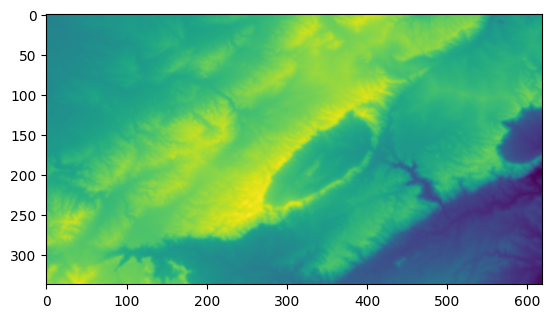

In [5]:
plt.imshow(dem)

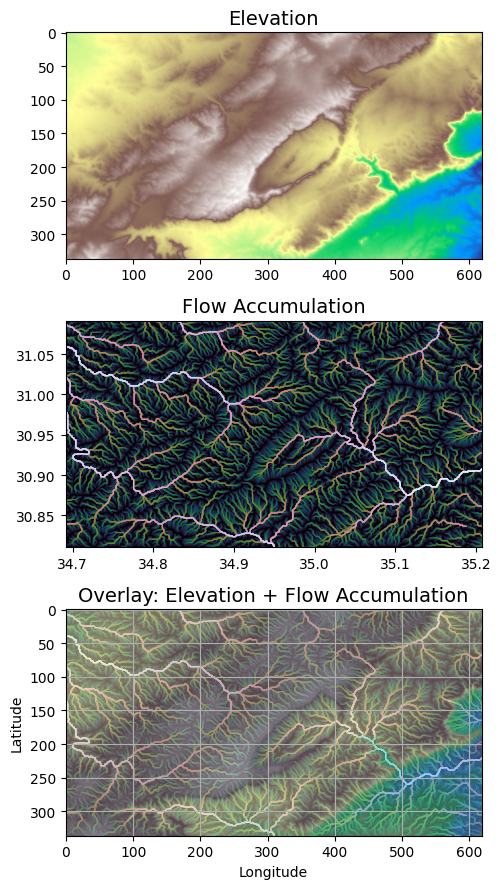

In [3]:

# Condition DEM
# ----------------------
if True:
    for _ in range(1):
    # Fill pits in DEM
        pit_filled_dem = grid.fill_pits(dem)

    # Fill depressions in DEM
        flooded_dem = grid.fill_depressions(pit_filled_dem)
        
    # Resolve flats in DEM
        dem = grid.resolve_flats(flooded_dem, max_iter=100000000, eps=1e-12)
inflated_dem = dem
flats = grid.detect_flats(inflated_dem)
grid.view(flats)

# Determine D8 flow directions from DEM
# ----------------------
# Specify directional mapping
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
    
# Compute flow directions
# -------------------------------------
fdir = grid.flowdir(inflated_dem, dirmap=dirmap)

# Calculate flow accumulation
# --------------------------
acc = grid.accumulation(fdir, dirmap=dirmap)

fig, ax = plt.subplots(3, 1, figsize=(8, 9))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax[1].imshow(acc, extent=grid.extent, zorder=2,
               cmap='cubehelix',
               norm=colors.LogNorm(1, acc.max()),
               interpolation='bilinear')
# plt.colorbar(im, ax=ax[0], label='Upstream Cells')
ax[1].set_title('Flow Accumulation', size=14)
ax[0].imshow(dem, cmap='terrain')
# plt.colorbar(ax[1].images[0], ax=ax[1], label='Elevation (m)')
ax[0].set_title('Elevation', size=14)
ax[2].imshow(dem, cmap='terrain', alpha=0.7)
ax[2].imshow(acc, cmap='cubehelix',
             norm=colors.LogNorm(1, acc.max()),
             interpolation='bilinear', alpha=0.5)
ax[2].set_title('Overlay: Elevation + Flow Accumulation', size=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()

plt.show()

In [54]:
# Delineate a catchment
# ---------------------
# Specify pour point
x, y = -97.294, 32.737

# Snap pour point to high accumulation cell
x_snap, y_snap = grid.snap_to_mask(acc > 1000, (x, y))

# Delineate the catchment
catch = grid.catchment(x=x_snap, y=y_snap, fdir=fdir, dirmap=dirmap, 
                       xytype='coordinate')

# Crop and plot the catchment
# ---------------------------
# Clip the bounding box to the catchment
grid.clip_to(catch)
clipped_catch = grid.view(catch)

In [55]:
import seaborn as sns
import numpy as np
branches = grid.extract_river_network(fdir, acc > 50, dirmap=dirmap)
sns.set_palette('husl')
fig, ax = plt.subplots(figsize=(8.5,6.5))

plt.xlim(grid.bbox[0], grid.bbox[2])
plt.ylim(grid.bbox[1], grid.bbox[3])
ax.set_aspect('equal')

for branch in branches['features']:
    line = np.asarray(branch['geometry']['coordinates'])
    plt.plot(line[:, 0], line[:, 1])
    
_ = plt.title('D8 channels', size=14)

In [56]:
dist = grid.distance_to_outlet(x=x_snap, y=y_snap, fdir=fdir, dirmap=dirmap,
                               xytype='coordinate')

fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_alpha(0)
plt.grid('on', zorder=0)
im = ax.imshow(dist, extent=grid.extent, zorder=2,
               cmap='cubehelix_r')
plt.colorbar(im, ax=ax, label='Distance to outlet (cells)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Flow Distance', size=14)

Text(0.5, 1.0, 'Flow Distance')